In [50]:
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

In [ ]:
df_items = pd.read_csv('./data_en/items_en.csv').drop('Unnamed: 0', axis=1)
df_users = pd.read_csv('./data_en/users_en.csv').drop('Unnamed: 0', axis=1)
df_iters = pd.read_csv('./data_en/interactions.csv')
df_iters['last_watch_dt'] = pd.to_datetime(df_iters['last_watch_dt'])
df_iters = df_iters[int(len(df_iters)*-0.5):]

In [52]:
test_size_weeks = 3
df_iters_test = df_iters[df_iters['last_watch_dt'].max() - df_iters['last_watch_dt'] < np.timedelta64(21) ]
df_iters_train = df_iters[df_iters['last_watch_dt'].max() - df_iters['last_watch_dt'] >= np.timedelta64(21) ]
df_iters_test = df_iters_test.groupby('item_id').filter(lambda group: len(group) > 2)
df_iters_train = df_iters_train.groupby('item_id').filter(lambda group: len(group) > 2)
# common_item_ids = df_interactions_test['item_id'].isin(df_interactions_train['item_id'])
# common_item_ids = common_item_ids[common_item_ids].index
# df_interactions_test = df_interactions_test[df_interactions_test['item_id'].isin(common_item_ids)]
# df_interactions_train = df_interactions_train[df_interactions_train['item_id'].isin(common_item_ids)]
print(f"length of df_iters_test: {len(df_iters_test)}")
print(f"length of df_iters_train: {len(df_iters_train)}")

length of df_iters_test: 33446
length of df_iters_train: 2697212


In [53]:
df_users_filtred = df_iters_test.groupby('user_id').filter(lambda group: len(group) > 1 and len(group) < 20)['user_id'].unique()
all_users = df_users['user_id'].unique()

df_users_filtred = df_users_filtred[np.isin(df_users_filtred, all_users)]
df_users_filtred

array([ 60494, 931364, 942580, ...,  92702, 214369, 382821], shape=(4454,))

In [54]:
df_items['genres_parsed'] = df_items['genres'].apply(lambda x: list(str(x).split(',')))
df_items['keywords_parsed'] = df_items['keywords'].apply(lambda x: list(str(x).split(',')))
df_items['actors_translated_parsed'] = df_items['actors_translated'].apply(lambda x: list(str(x).split(',')))
df_items['directors_translated_parsed'] = df_items['directors_translated'].apply(lambda x: list(str(x).split(',')))

In [55]:
# users_with_views = df_interactions_test['user_id'].unique()
users_with_views = df_iters_test.groupby('user_id').filter(lambda group: len(group) > 2 and len(group) < 20)['user_id'].unique()
all_users = df_users['user_id'].unique()

flags = np.isin(users_with_views, all_users)
users_with_views = users_with_views[flags]

In [56]:
class ALS:
    def __init__(self, n_factors=10, alpha=40, regularization=0.1, iterations=15):
        """
        Инициализация ALS модели
        
        Parameters:
        - n_factors: количество латентных факторов
        - alpha: параметр уверенности для неявной обратной связи
        - regularization: коэффициент регуляризации (lambda)
        - iterations: количество итераций обучения
        """
        self.n_factors = n_factors
        self.alpha = alpha
        self.regularization = regularization
        self.iterations = iterations
        self.user_factors = None
        self.item_factors = None
        self.loss_history = []
    
    def fit(self, ratings):
        """
        Обучение ALS модели
        
        Parameters:
        - ratings: scipy sparse matrix в формате (users × items)
        """
        n_users, n_items = ratings.shape
        
        # Инициализация матриц факторов
        self.user_factors = np.random.normal(0, 0.1, (n_users, self.n_factors))
        self.item_factors = np.random.normal(0, 0.1, (n_items, self.n_factors))
        
        print("Начинаем обучение ALS...")
        
        for iteration in range(self.iterations):
            # Шаг 1: Фиксируем item factors, обновляем user factors
            for u in range(n_users):
                # Получаем индексы и значения оценок пользователя
                user_ratings = ratings[u].toarray().flatten()
                rated_items = np.where(user_ratings > 0)[0]
                
                if len(rated_items) > 0:
                    # Вычисляем уверенности для неявной обратной связи
                    confidence = 1 + self.alpha * user_ratings[rated_items]
                    
                    # Матрица item factors для оцененных items
                    Y = self.item_factors[rated_items]
                    
                    # Вычисляем матрицу A и вектор b
                    C = np.diag(confidence)
                    A = Y.T @ C @ Y + self.regularization * np.eye(self.n_factors)
                    b = Y.T @ confidence
                    
                    # Решаем линейную систему
                    self.user_factors[u] = np.linalg.solve(A, b)
            
            # Шаг 2: Фиксируем user factors, обновляем item factors
            for i in range(n_items):
                # Получаем индексы и значения оценок для item
                item_ratings = ratings[:, i].toarray().flatten()
                rating_users = np.where(item_ratings > 0)[0]
                
                if len(rating_users) > 0:
                    # Вычисляем уверенности
                    confidence = 1 + self.alpha * item_ratings[rating_users]
                    
                    # Матрица user factors для оценивших пользователей
                    X = self.user_factors[rating_users]
                    
                    # Вычисляем матрицу A и вектор b
                    C = np.diag(confidence)
                    A = X.T @ C @ X + self.regularization * np.eye(self.n_factors)
                    b = X.T @ confidence
                    
                    # Решаем линейную систему
                    self.item_factors[i] = np.linalg.solve(A, b)
            
            # Вычисляем loss
            loss = self._compute_loss(ratings)
            self.loss_history.append(loss)
            print(f"Итерация {iteration + 1}/{self.iterations}, Loss: {loss:.4f}")
    
    def _compute_loss(self, ratings):
        """Вычисление функции потерь"""
        loss = 0
        n_users, n_items = ratings.shape
        
        for u in range(n_users):
            for i in range(n_items):
                if ratings[u, i] > 0:
                    prediction = self.user_factors[u] @ self.item_factors[i]
                    confidence = 1 + self.alpha * ratings[u, i]
                    error = confidence - prediction
                    loss += error ** 2
        
        # Добавляем регуляризацию
        reg_loss = self.regularization * (
            np.sum(self.user_factors ** 2) + np.sum(self.item_factors ** 2)
        )
        
        return loss + reg_loss
    
    def predict(self, user_id, item_id):
        """Предсказание оценки"""
        return self.user_factors[user_id] @ self.item_factors[item_id]
    
    def recommend(self, user_id, n_recommendations=10):
        """Рекомендации для пользователя"""
        user_vector = self.user_factors[user_id]
        scores = user_vector @ self.item_factors.T
        top_items = np.argsort(scores)[::-1][:n_recommendations]
        return top_items, scores[top_items]
    
    def plot_loss(self):
        """Визуализация истории потерь"""
        plt.figure(figsize=(10, 6))
        plt.plot(self.loss_history, marker='o')
        plt.title('История обучения ALS')
        plt.xlabel('Итерация')
        plt.ylabel('Loss')
        plt.grid(True)
        plt.show()

In [57]:
from sklearn.preprocessing import LabelEncoder
import scipy.sparse as sp
def create_sparse_interaction_matrix(users_with_views, df_interactions_train, df_items):
    """
    Создает разреженную матрицу взаимодействий пользователь-предмет
    
    Parameters:
    -----------
    users_with_views : list
        Список пользователей для включения в матрицу
    df_interactions_train : pd.DataFrame
        Тренировочные взаимодействия со столбцами ['user_id', 'item_id', 'watched_pct']
    df_items : pd.DataFrame
        Список всех предметов
    
    Returns:
    --------
    sparse_matrix : scipy.sparse.csr_matrix
        Разреженная матрица взаимодействий
    user_encoder : LabelEncoder
        Кодировщик user_id в индексы строк
    item_encoder : LabelEncoder  
        Кодировщик item_id в индексы столбцов
    """
    
    # Фильтруем взаимодействия только для нужных пользователей
    filtered_interactions = df_interactions_train[
        df_interactions_train['user_id'].isin(users_with_views)
    ].copy()
    
    # Создаем кодировщики для пользователей и предметов
    user_encoder = LabelEncoder()
    item_encoder = LabelEncoder()
    
    # Подготавливаем всех возможных пользователей и предметы
    all_users = sorted(users_with_views)
    all_items = sorted(df_items['item_id'].unique())
    
    # Обучаем кодировщики
    user_encoder.fit(all_users)
    item_encoder.fit(all_items)
    
    # Преобразуем user_id и item_id в числовые индексы
    user_indices = user_encoder.transform(filtered_interactions['user_id'])
    item_indices = item_encoder.transform(filtered_interactions['item_id'])
    
    def vals(vs):
        return vs/100 if vs>50 else 0
    # Вычисляем значения watched_pct / 100
    values = filtered_interactions['watched_pct'].apply(vals)
    
    # Создаем разреженную матрицу в формате COO
    sparse_matrix = sp.coo_matrix(
        (values, (user_indices, item_indices)),
        shape=(len(all_users), len(all_items))
    )
    
    # Конвертируем в CSR для эффективных операций
    sparse_matrix_csr = sparse_matrix.tocsr()
    
    return sparse_matrix_csr, user_encoder, item_encoder

In [58]:
sparse_matrix_csr, user_encoder, item_encoder = create_sparse_interaction_matrix(users_with_views, df_iters_test, df_items)
sparse_matrix_csr

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4686 stored elements and shape (1307, 15963)>

In [59]:
len(df_iters_train)

2697212

Начинаем обучение ALS...
Итерация 1/40, Loss: 2179983.8395
Итерация 2/40, Loss: 2179643.8700
Итерация 3/40, Loss: 2179462.7111
Итерация 4/40, Loss: 2179329.0825
Итерация 5/40, Loss: 2179222.0254
Итерация 6/40, Loss: 2179133.1290
Итерация 7/40, Loss: 2179057.4023
Итерация 8/40, Loss: 2178991.4243
Итерация 9/40, Loss: 2178933.6882
Итерация 10/40, Loss: 2178882.6093
Итерация 11/40, Loss: 2178836.8863
Итерация 12/40, Loss: 2178795.6210
Итерация 13/40, Loss: 2178758.1295
Итерация 14/40, Loss: 2178723.8708
Итерация 15/40, Loss: 2178692.4126
Итерация 16/40, Loss: 2178663.3932
Итерация 17/40, Loss: 2178636.5276
Итерация 18/40, Loss: 2178611.5803
Итерация 19/40, Loss: 2178588.3481
Итерация 20/40, Loss: 2178566.6543
Итерация 21/40, Loss: 2178546.3414
Итерация 22/40, Loss: 2178527.2587
Итерация 23/40, Loss: 2178509.3512
Итерация 24/40, Loss: 2178492.4525
Итерация 25/40, Loss: 2178476.5128
Итерация 26/40, Loss: 2178461.4000
Итерация 27/40, Loss: 2178447.1360
Итерация 28/40, Loss: 2178433.6299
Итер

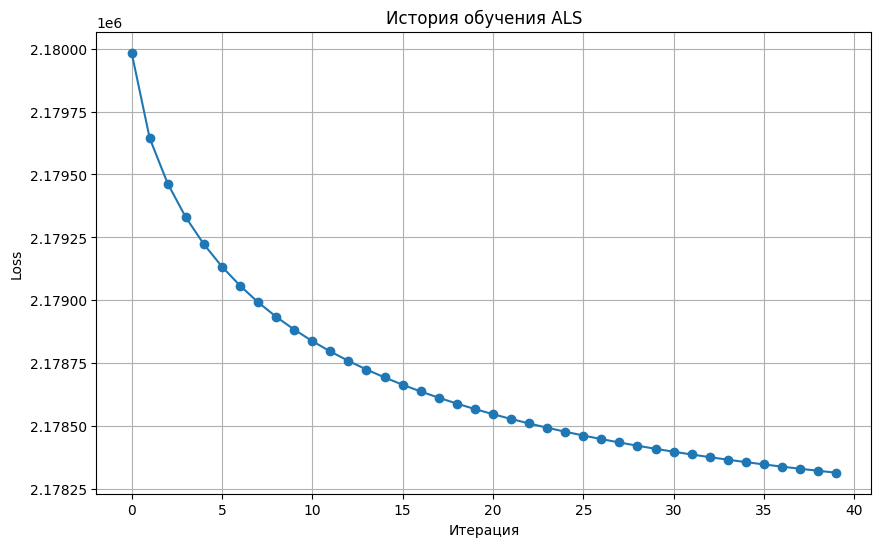

In [60]:
als_model = ALS(
        n_factors=10,
        alpha=40,
        regularization=0.1,
        iterations=40
    )
# Обучение модели
als_model.fit(sparse_matrix_csr)
    
# Визуализация процесса обучения
als_model.plot_loss()

In [62]:
import pickle
import os

MODEL_DIR = "models"
MODEL_PATH = os.path.join(MODEL_DIR, "als_model.pkl")

with open(MODEL_PATH, 'wb') as f:
    pickle.dump(als_model, f)
print(f"✅ Модель сохранена: {MODEL_PATH}")

✅ Модель сохранена: models\als_model.pkl


In [77]:
als_model.recommend(1306, n_recommendations=10)

(array([ 5232, 13998,  8512,  6605,  9393, 10650,  3243,  9147, 12761,
         9560]),
 array([0.15242418, 0.14927026, 0.14387339, 0.14137813, 0.13671827,
        0.12940934, 0.12797778, 0.12149248, 0.11844131, 0.11629478]))

In [88]:
recommended_list = []
watched_list = []

#us_list = df_iters_test['user_id'].unique()
l = int(len(users_with_views)*1)

for i in range(1307):
    uid = user_encoder.inverse_transform([i])[0]
    rec = als_model.recommend(i, n_recommendations=10)[0]

    watched_list.append(df_iters_test[df_iters_test["user_id"]==uid]["item_id"].tolist())
    recommended_list.append(rec)
    print(f'{i}/{l}')

0/1307
1/1307
2/1307
3/1307
4/1307
5/1307
6/1307
7/1307
8/1307
9/1307
10/1307
11/1307
12/1307
13/1307
14/1307
15/1307
16/1307
17/1307
18/1307
19/1307
20/1307
21/1307
22/1307
23/1307
24/1307
25/1307
26/1307
27/1307
28/1307
29/1307
30/1307
31/1307
32/1307
33/1307
34/1307
35/1307
36/1307
37/1307
38/1307
39/1307
40/1307
41/1307
42/1307
43/1307
44/1307
45/1307
46/1307
47/1307
48/1307
49/1307
50/1307
51/1307
52/1307
53/1307
54/1307
55/1307
56/1307
57/1307
58/1307
59/1307
60/1307
61/1307
62/1307
63/1307
64/1307
65/1307
66/1307
67/1307
68/1307
69/1307
70/1307
71/1307
72/1307
73/1307
74/1307
75/1307
76/1307
77/1307
78/1307
79/1307
80/1307
81/1307
82/1307
83/1307
84/1307
85/1307
86/1307
87/1307
88/1307
89/1307
90/1307
91/1307
92/1307
93/1307
94/1307
95/1307
96/1307
97/1307
98/1307
99/1307
100/1307
101/1307
102/1307
103/1307
104/1307
105/1307
106/1307
107/1307
108/1307
109/1307
110/1307
111/1307
112/1307
113/1307
114/1307
115/1307
116/1307
117/1307
118/1307
119/1307
120/1307
121/1307
122/1307
123

In [90]:
def precision_at_k(recommended_list, watched_list, k=5):
    
    watched_list = np.array(watched_list)
    recommended_list = np.array(recommended_list)
    
    #assert len(watched_list) > len(recommended_list)
    watched_list = watched_list  # Тут нет [:k] !!
    recommended_list = recommended_list[:k]
    
    flags = np.isin(watched_list, recommended_list)
    
    precision = flags.sum() / len(recommended_list)
    
    
    return precision

def ap_k(recommended_list, watched_list, k=5):
    
    watched_list = np.array(watched_list)
    recommended_list = np.array(recommended_list)
    
    flags = np.isin(recommended_list, watched_list)
    
    if sum(flags) == 0:
        return 0
    
    sum_ = 0
    for i in range(0, k-1):
        if flags[i] == True:
            p_k = precision_at_k(recommended_list, watched_list, k=i+1)
            sum_ += p_k
            
    result = sum_ / sum(flags)
    
    return result

def map_k(recommended_list, watched_list, k=5, u=1):

    sum_ = 0
    for i in range(len(recommended_list)):
        sum_ += ap_k(recommended_list[i], watched_list[i], k)
    
    result = sum_ / u

    return result

In [95]:
map_k(recommended_list, watched_list, 10, 1307)

np.float64(0.00018065119442319135)

In [92]:
recommended_list[0]

array([ 9925,   380, 13790,  3795,  5614,  2947,  9143,  1527,  2347,
        9285])

In [93]:
watched_list[0]

[7102, 14282, 391]

-------------------------------

In [97]:
test_predictions = []
test_actual = []
    
for u in range(sparse_matrix_csr.shape[0]):
    for i in range(sparse_matrix_csr.shape[1]):
        if sparse_matrix_csr[u, i] > 0:
                pred = als_model.predict(u, i)
                test_predictions.append(pred)
                test_actual.append(sparse_matrix_csr[u, i])
    
# Вычисляем метрики
mse = mean_squared_error(test_actual, test_predictions)
rmse = np.sqrt(mse)
    
print(f"RMSE на тестовой выборке: {rmse:.4f}")
    
    # Демонстрация рекомендаций
print("\nДемонстрация рекомендаций:")
user_id = 0
recommended_items, scores = als_model.recommend(user_id, n_recommendations=10)
    
print(f"Топ-10 рекомендаций для пользователя {user_id}:")
for i, (item, score) in enumerate(zip(`recommended_items`, scores)):
    print(f"{i+1}. Item {item} (score: {score:.3f})")
    
    # Анализ факторов
print(f"\nАнализ модели:")
print(f"Размерность user_factors: {als_model.user_factors.shape}")
print(f"Размерность item_factors: {als_model.item_factors.shape}")
print(f"Общее количество параметров: {als_model.user_factors.size + als_model.item_factors.size}")

RMSE на тестовой выборке: 0.1665

Демонстрация рекомендаций:
Топ-10 рекомендаций для пользователя 0:
1. Item 9925 (score: 1.008)
2. Item 380 (score: 0.999)
3. Item 13790 (score: 0.999)
4. Item 3795 (score: 0.967)
5. Item 5614 (score: 0.887)
6. Item 2947 (score: 0.863)
7. Item 9143 (score: 0.855)
8. Item 1527 (score: 0.853)
9. Item 2347 (score: 0.850)
10. Item 9285 (score: 0.845)

Анализ модели:
Размерность user_factors: (1307, 10)
Размерность item_factors: (15963, 10)
Общее количество параметров: 172700


In [101]:
def new_metric(recommended_list, watched_list):
    rec = np.array(recommended_list)
    wat = np.array(watched_list)
    inter = wat - rec 
    inter = np.abs(inter)
    return inter.sum() / len(inter)


In [99]:
def progress_bar(current, total, bar_length=50, append=""):
    fraction = current / total
    arrow = int(fraction * bar_length - 1) * '=' + '>'
    padding = (bar_length - len(arrow)) * ' '
    
    progress = f'Progress: [{arrow}{padding}] {int(fraction*100)}%\t{current}/{total}' + append
    print(progress, end='\r')
    
    if current == total: 
        print()

In [102]:
map_10 = 0

test_predictions = []
test_actual = []
    
for u in range(sparse_matrix_csr.shape[0]):
    progress_bar(u, sparse_matrix_csr.shape[0])
    for i in range(sparse_matrix_csr.shape[1]):
        if sparse_matrix_csr[u, i] > 0:
            pred = als_model.predict(u, i)
            test_predictions.append(pred)
            test_actual.append(sparse_matrix_csr[u, i])

    test_predictions = np.array(test_predictions)
    test_actual = np.array(test_actual)
    if len(test_actual) != 0:
        map_10 += new_metric(test_predictions, test_actual)
    test_predictions = []
    test_actual = []
        # break

map_10 /= len(users_with_views)
map_10

# test_actual, test_predictions

np.float64(0.06734457966982399)